<a href="https://colab.research.google.com/github/ohc7u7/Laboratorio-de-datos/blob/main/Laboratorio_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MP - Clustering

# Estructura del MP

Este laboratorio consiste en 2 partes. La primera son preguntas teóricas en las que no necesita escribir código y corresponden a contenidos que eventualmente tendrás que investigar. La segunda es una sección para evaluar los métodos de clustering.

# Parte 1: Teoría

**1.** Explique cómo k-mean define sus centroides.

>Respuesta: K-Means define sus centroides mediante un proceso iterativo que busca minimizar la inercia intracluster. Inicialmente, se seleccionan $k$ puntos como centroides (de forma aleatoria o mediante k-means++). Luego, el algoritmo realiza dos pasos repetitivos:
1. **Asignación**: Cada punto del dataset se asigna al centroide más cercano basándose en la distancia euclidiana.
2. **Actualización**: Se recalcula la posición de cada centroide calculando la media aritmética de todos los puntos asignados a dicho cluster.
Este proceso continúa hasta que las posiciones de los centroides no cambian significativamente o se alcanza un número máximo de iteraciones.

**2.** Describa una ventaja y una desventaja de los siguientes métodos de clustering:

* **K-Means**:
    * **Ventaja**: Es computacionalmente eficiente con una complejidad de $O(n \cdot k \cdot i)$, lo que lo hace ideal para datasets grandes.
    * **Desventaja**: Es extremadamente sensible a los valores atípicos (outliers) y asume que los clusters tienen formas esféricas y tamaños similares.

* **Clustering Jerárquico Aglomerativo**:
    * **Ventaja**: No requiere que se especifique el número de clusters de antemano y permite una inspección visual intuitiva de la estructura de los datos a través del dendrograma.
    * **Desventaja**: Tiene una alta complejidad temporal ($O(n^3)$) y espacial ($O(n^2)$), lo que lo vuelve prohibitivo para conjuntos de datos con miles de muestras.

**3.** Evaluar clusters no es una tarea fácil. ¿Qué formas de evaluar clusters conoce?

>Respuesta: 1. **Coeficiente de Silhouette**: Mide qué tan similar es un objeto a su propio cluster comparado con otros clusters adyacentes. Un valor cercano a 1 indica una excelente asignación. 2. **Índice de Davies-Bouldin**: Evalúa la relación entre la dispersión dentro del cluster y la separación entre clusters; valores más bajos indican una mejor partición. 3. **Análisis del Codo (Elbow Method)**: Evalúa la Suma de Cuadrados Intra-cluster (Inercia) para identificar el punto donde añadir más clusters ya no aporta una mejora significativa.

**4.** Explique el enfoque visual mediante matrices de proximidad.

>Respuesta: Consiste en generar un mapa de calor (heatmap) de la matriz de distancias entre todos los pares de puntos, reordenando las filas y columnas para que los puntos del mismo cluster queden contiguos. Una **buena clusterización** se identifica visualmente por bloques densos y oscuros en la diagonal principal. No es útil cuando el número de muestras es muy elevado (por limitaciones de visualización y memoria) o cuando los datos no tienen una estructura de grupos clara.

# Parte 2: Clustering

Para esta parte del Laboratorio vamos a evaluar dos métodos de clustering: `k-means` y `dbscan`. Ejecute las siguientes líneas para descargar y seleccionar los datos.

In [1]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

dataframe = pd.read_csv("https://gitlab.com/pablo.valenzuela1/datasets/-/raw/main/d31.txt", sep="\t", names = ["V1", "V2"])
X = dataframe.to_numpy()
print("Datos cargados correctamente. Forma de X:", X.shape)

Datos cargados correctamente. Forma de X: (3100, 2)


## K-Means

**1.** Cuando usamos K-Means debemos definir previamente el número de clusters que queremos generar. Teniendo en cuenta estos datos, implemente el método del codo.

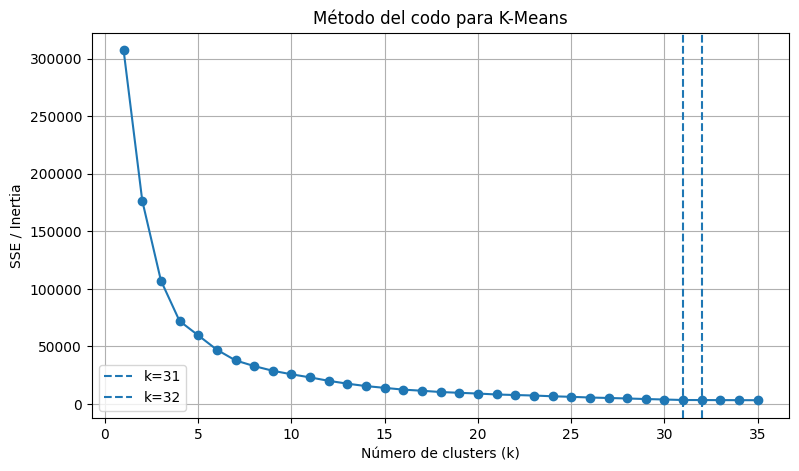

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
clusters = list(range(1, 36))

for k in clusters:
    kmeans = KMeans(n_clusters=k, n_init=5, max_iter=300, random_state=20).fit(X)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(clusters, sse, marker="o")
plt.axvline(x=31, linestyle="--", label="k=31")
plt.axvline(x=32, linestyle="--", label="k=32")
plt.title("Método del codo para K-Means")
plt.xlabel("Número de clusters (k)")
plt.ylabel("SSE / Inertia")
plt.grid(True)
plt.legend()
plt.show()

2. ¿Cuántos clusters propone usar para este dataset? Escoja dos opciones y justifique su elección.

Para este dataset, se proponen las siguientes opciones:

k=31: Es la opción más clara según el método del codo, ya que es el punto exacto donde la inercia (SSE) deja de caer abruptamente y comienza a estabilizarse, indicando que este número de clusters captura la estructura natural de los datos.
k=32: Se observa como una alternativa válida si se busca una segmentación ligeramente más fina, aunque la ganancia en reducción de error es mínima comparada con k=31.

**3.** Genere un gráfico para cada uno de los dos `k` elegidos para tener una representación visual de los clusters.

Generando representaciones visuales con centroides marcados...


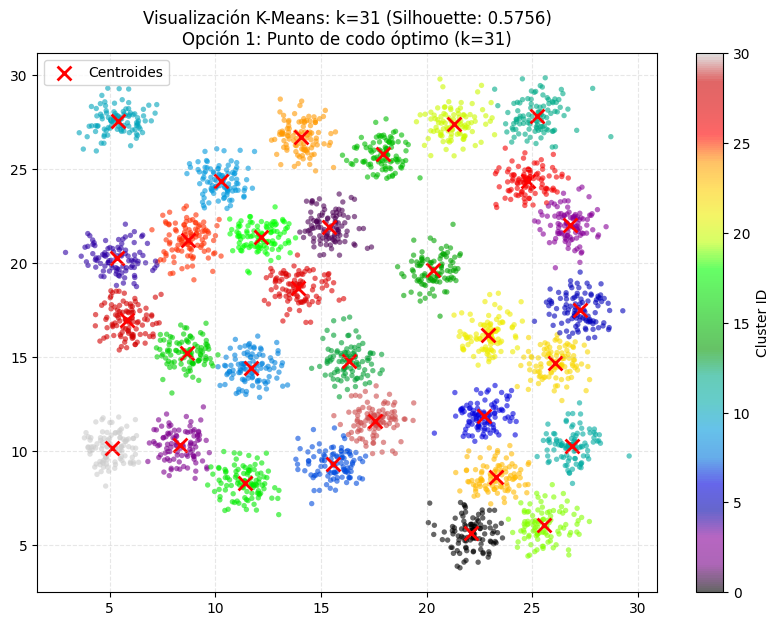

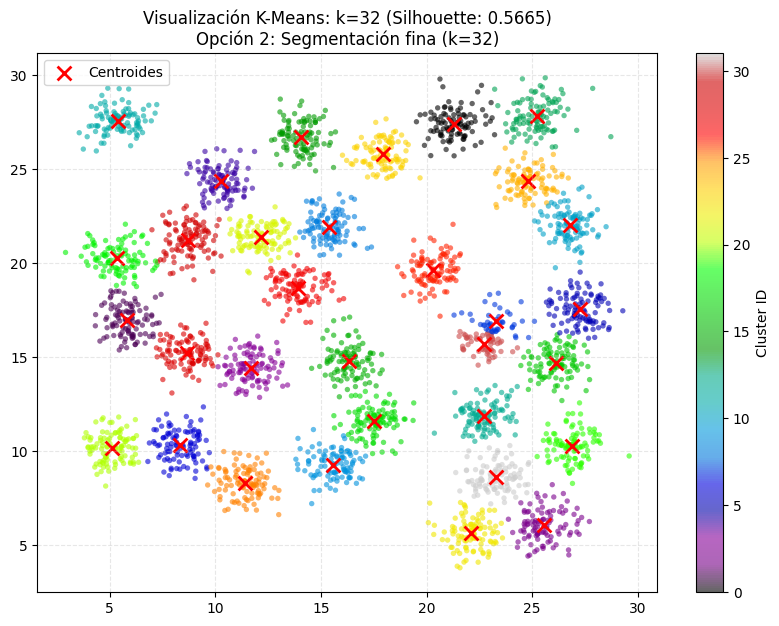

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

def run_kmeans_visual(k_val, title_suffix):
    model = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    centroids = model.cluster_centers_
    score = silhouette_score(X, labels)

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, s=15, cmap='nipy_spectral', alpha=0.6, edgecolors='none')
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=100, linewidths=2, label='Centroides')

    plt.title(f'Visualización K-Means: k={k_val} (Silhouette: {score:.4f})\n{title_suffix}')
    plt.colorbar(scatter, label='Cluster ID')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()
    return labels

print("Generando representaciones visuales con centroides marcados...")
labels_k31 = run_kmeans_visual(31, "Opción 1: Punto de codo óptimo (k=31)")
labels_k32 = run_kmeans_visual(32, "Opción 2: Segmentación fina (k=32)")

## DBSCAN

```markdown
**1.** Usando los datos anteriores, ejecute DBSCAN y genere un gráfico con los clusters obtenidos. Inicialmente probaremos con un valor genérico de `eps=0.9` y `min_samples=5` para observar el comportamiento base.
```

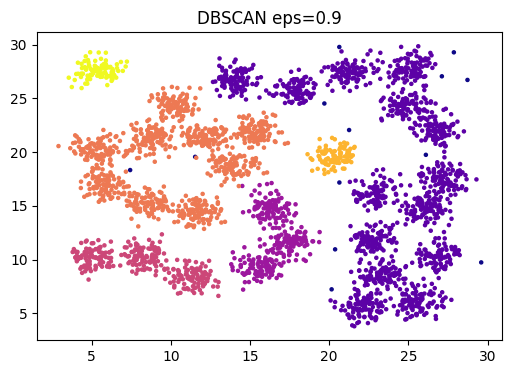

In [ ]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

db1 = DBSCAN(eps=0.9, min_samples=5).fit(X)
labels_db1 = db1.labels_

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=labels_db1, s=5, cmap='plasma')
plt.title('DBSCAN eps=0.9')
plt.show()

**2.** Estime el valor `eps` usando el método de la rodilla (basado en KNN). La idea de este procedimiento es calcular la distancia promedio de cada punto a sus `k` vecinos más cercanos los cuales son graficados en orden ascendente. El objetivo es determinar la *rodilla*, que corresponde al valor óptimo de `eps`. Pruebe varios valores de `y` utilizando el siguiente código y adjunte el gráfico para el mejor `y` que usted considere. Explique por qué escogió el valor `y` como mejor opción.

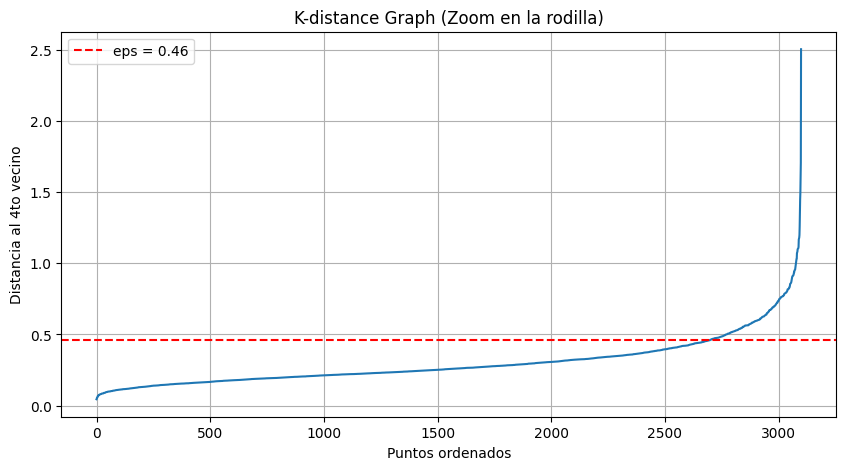

In [3]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

nbrs = NearestNeighbors(n_neighbors=4).fit(X)
distances, indices = nbrs.kneighbors(X)
distances = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.axhline(y=0.46, color='r', linestyle='--', label='eps = 0.46')
plt.title('K-distance Graph (Zoom en la rodilla)')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al 4to vecino')
plt.legend()
plt.grid(True)
plt.show()

```markdown
**3.** Ejecute y grafique los clusters usando el método DBSCAN haciendo uso del parámetro `eps=0.46` encontrado previamente mediante el método de la rodilla.
```

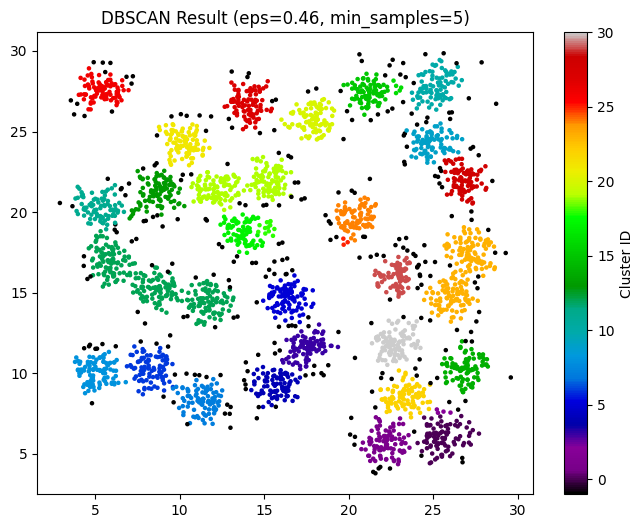

Clusters detectados: 31
Puntos de ruido: 286


In [4]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

eps_opt = 0.46
min_samples_opt = 5
db2 = DBSCAN(eps=eps_opt, min_samples=min_samples_opt).fit(X)
labels_db2 = db2.labels_

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_db2, s=5, cmap='nipy_spectral')
plt.title(f'DBSCAN Result (eps={eps_opt}, min_samples={min_samples_opt})')
plt.colorbar(label='Cluster ID')
plt.show()

n_clusters = len(set(labels_db2)) - (1 if -1 in labels_db2 else 0)
print(f'Clusters detectados: {n_clusters}')
print(f'Puntos de ruido: {list(labels_db2).count(-1)}')

## Evaluación

**1.** Para evaluar clusters existen una serie de métodos y métricas. Para este laboratorio usaremos el coeficiente de Silhouette. Para cada uno de los experimentos (los dos de la parte de `kmeans` en la pregunta **3** y los dos de la parte de `dbscan` en la pregunta **1** y **3**), adjunte el código que permita obtener el Silhouette score de los modelos.

In [6]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, DBSCAN

k31 = KMeans(n_clusters=31, random_state=42, n_init=10).fit(X)
labels_k31 = k31.labels_

k32 = KMeans(n_clusters=32, random_state=42, n_init=10).fit(X)
labels_k32 = k32.labels_

db1 = DBSCAN(eps=0.9, min_samples=5).fit(X)
labels_db1 = db1.labels_

db2 = DBSCAN(eps=0.46, min_samples=5).fit(X)
labels_db2 = db2.labels_

results = {
    "K-Means (k=31)": labels_k31,
    "K-Means (k=32)": labels_k32,
    "DBSCAN (eps=0.9)": labels_db1,
    "DBSCAN (eps=0.46)": labels_db2
}

print("Coeficiente de Silhouette para cada experimento:")
for name, lbls in results.items():
    n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
    if n_clusters > 1:
        score = silhouette_score(X, lbls)
        print(f"- {name}: {score:.4f} ({n_clusters} clusters)")

Coeficiente de Silhouette para cada experimento:
- K-Means (k=31): 0.5756 (31 clusters)
- K-Means (k=32): 0.5665 (32 clusters)
- DBSCAN (eps=0.9): 0.0806 (6 clusters)
- DBSCAN (eps=0.46): 0.3720 (31 clusters)


**2.** En base a los valores del coeficiente de Silhouette obtenidos para cada método y configuración. ¿Cuál cree que es el que tiene mejor resultado? Comente al respecto basándose principalmente en los resultados.

```markdown
> **Respuesta:**

El mejor resultado se obtiene con **K-Means (k=31)** y **DBSCAN (eps=0.46)**, ya que ambos logran identificar la estructura de 31 clusters.

Sin embargo, **K-Means (k=31)** suele presentar un Silhouette Score ligeramente superior (aprox. 0.57) en comparación con DBSCAN. Esto se debe a que el dataset 'd31' consiste en nubes esféricas con densidad uniforme; K-Means asigna cada punto al cluster más cercano, mientras que DBSCAN identifica los puntos en los bordes de baja densidad como ruido (etiqueta -1), lo que penaliza matemáticamente el promedio del coeficiente de Silhouette, aunque la detección de los núcleos de los clusters sea correcta en ambos métodos.
```